In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load processed datasets
btc_df = pd.read_csv('../data/processed/BTC_USDT_processed.csv')
eth_df = pd.read_csv('../data/processed/ETH_USDT_processed.csv')

# Convert timestamp
btc_df['timestamp'] = pd.to_datetime(btc_df['timestamp'])
eth_df['timestamp'] = pd.to_datetime(eth_df['timestamp'])

print("BTC dataset:")
print(f"  Shape: {btc_df.shape}")
print(f"  Label distribution: {btc_df['label'].value_counts().to_dict()}")

print("\nETH dataset:")
print(f"  Shape: {eth_df.shape}")
print(f"  Label distribution: {eth_df['label'].value_counts().to_dict()}")

BTC dataset:
  Shape: (3900, 36)
  Label distribution: {1: 1992, 0: 996, 2: 912}

ETH dataset:
  Shape: (7187, 36)
  Label distribution: {1: 3638, 2: 1819, 0: 1730}


In [3]:
# Columns to drop (not useful for ML)
DROP_COLS = ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'future_return']

# Features and target
FEATURE_COLS = [c for c in btc_df.columns if c not in DROP_COLS + ['label']]
TARGET_COL = 'label'

print(f"Number of features: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS}")

Number of features: 28
Features: ['ma20', 'ma50', 'rsi', 'returns', 'vol_20', 'macd', 'macd_signal', 'macd_diff', 'bb_high', 'bb_low', 'bb_mid', 'bb_width', 'atr', 'stoch_rsi', 'stoch_rsi_k', 'stoch_rsi_d', 'close_lag_1', 'returns_lag_1', 'close_lag_2', 'returns_lag_2', 'close_lag_3', 'returns_lag_3', 'close_lag_6', 'returns_lag_6', 'close_lag_12', 'returns_lag_12', 'close_lag_24', 'returns_lag_24']


In [4]:
def prepare_data(df):
    X = df[FEATURE_COLS]
    y = df[TARGET_COL]
    
    # Time series split — NO random shuffle!
    # Past data trains, future data tests (realistic trading scenario)
    split_idx = int(len(df) * 0.8)
    
    X_train = X.iloc[:split_idx]
    X_test  = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    
    print(f"Train size: {len(X_train)} rows ({split_idx/len(df)*100:.0f}%)")
    print(f"Test size:  {len(X_test)} rows ({(len(df)-split_idx)/len(df)*100:.0f}%)")
    
    return X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, scaler

print("BTC split:")
btc_X_train, btc_X_test, btc_y_train, btc_y_test, btc_X_train_sc, btc_X_test_sc, btc_scaler = prepare_data(btc_df)

print("\nETH split:")
eth_X_train, eth_X_test, eth_y_train, eth_y_test, eth_X_train_sc, eth_X_test_sc, eth_scaler = prepare_data(eth_df)

BTC split:
Train size: 3120 rows (80%)
Test size:  780 rows (20%)

ETH split:
Train size: 5749 rows (80%)
Test size:  1438 rows (20%)


In [5]:
print("Training Random Forest...")
print("="*50)

# BTC
rf_btc = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)
rf_btc.fit(btc_X_train, btc_y_train)
rf_btc_pred = rf_btc.predict(btc_X_test)

print("BTC - Random Forest:")
print(f"  Accuracy: {accuracy_score(btc_y_test, rf_btc_pred)*100:.2f}%")
print(classification_report(btc_y_test, rf_btc_pred, 
      target_names=['SELL', 'HOLD', 'BUY']))

# ETH
rf_eth = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)
rf_eth.fit(eth_X_train, eth_y_train)
rf_eth_pred = rf_eth.predict(eth_X_test)

print("ETH - Random Forest:")
print(f"  Accuracy: {accuracy_score(eth_y_test, rf_eth_pred)*100:.2f}%")
print(classification_report(eth_y_test, rf_eth_pred,
      target_names=['SELL', 'HOLD', 'BUY']))

Training Random Forest...
BTC - Random Forest:
  Accuracy: 58.72%
              precision    recall  f1-score   support

        SELL       0.51      0.35      0.41       186
        HOLD       0.61      0.85      0.71       393
         BUY       0.58      0.29      0.39       201

    accuracy                           0.59       780
   macro avg       0.56      0.50      0.50       780
weighted avg       0.58      0.59      0.56       780

ETH - Random Forest:
  Accuracy: 54.38%
              precision    recall  f1-score   support

        SELL       0.38      0.11      0.17       316
        HOLD       0.55      0.92      0.69       758
         BUY       0.56      0.13      0.21       364

    accuracy                           0.54      1438
   macro avg       0.50      0.39      0.36      1438
weighted avg       0.52      0.54      0.46      1438



In [6]:
print("Training XGBoost...")
print("="*50)

# BTC
xgb_btc = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)
xgb_btc.fit(btc_X_train, btc_y_train)
xgb_btc_pred = xgb_btc.predict(btc_X_test)

print("BTC - XGBoost:")
print(f"  Accuracy: {accuracy_score(btc_y_test, xgb_btc_pred)*100:.2f}%")
print(classification_report(btc_y_test, xgb_btc_pred,
      target_names=['SELL', 'HOLD', 'BUY']))

# ETH
xgb_eth = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)
xgb_eth.fit(eth_X_train, eth_y_train)
xgb_eth_pred = xgb_eth.predict(eth_X_test)

print("ETH - XGBoost:")
print(f"  Accuracy: {accuracy_score(eth_y_test, xgb_eth_pred)*100:.2f}%")
print(classification_report(eth_y_test, xgb_eth_pred,
      target_names=['SELL', 'HOLD', 'BUY']))

Training XGBoost...
BTC - XGBoost:
  Accuracy: 58.46%
              precision    recall  f1-score   support

        SELL       0.49      0.40      0.44       186
        HOLD       0.63      0.80      0.70       393
         BUY       0.54      0.33      0.41       201

    accuracy                           0.58       780
   macro avg       0.55      0.51      0.52       780
weighted avg       0.57      0.58      0.56       780

ETH - XGBoost:
  Accuracy: 56.33%
              precision    recall  f1-score   support

        SELL       0.46      0.27      0.34       316
        HOLD       0.59      0.83      0.69       758
         BUY       0.50      0.26      0.35       364

    accuracy                           0.56      1438
   macro avg       0.52      0.45      0.46      1438
weighted avg       0.54      0.56      0.53      1438



In [7]:
from sklearn.neural_network import MLPClassifier

print("Training Neural Network...")
print("="*50)

# BTC
nn_btc = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)
nn_btc.fit(btc_X_train_sc, btc_y_train)
nn_btc_pred = nn_btc.predict(btc_X_test_sc)

print("BTC - Neural Network:")
print(f"  Accuracy: {accuracy_score(btc_y_test, nn_btc_pred)*100:.2f}%")
print(classification_report(btc_y_test, nn_btc_pred,
      target_names=['SELL', 'HOLD', 'BUY']))

# ETH
nn_eth = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)
nn_eth.fit(eth_X_train_sc, eth_y_train)
nn_eth_pred = nn_eth.predict(eth_X_test_sc)

print("ETH - Neural Network:")
print(f"  Accuracy: {accuracy_score(eth_y_test, nn_eth_pred)*100:.2f}%")
print(classification_report(eth_y_test, nn_eth_pred,
      target_names=['SELL', 'HOLD', 'BUY']))

Training Neural Network...
BTC - Neural Network:
  Accuracy: 50.51%
              precision    recall  f1-score   support

        SELL       0.32      0.19      0.24       186
        HOLD       0.56      0.83      0.67       393
         BUY       0.39      0.17      0.24       201

    accuracy                           0.51       780
   macro avg       0.42      0.39      0.38       780
weighted avg       0.46      0.51      0.45       780

ETH - Neural Network:
  Accuracy: 51.81%
              precision    recall  f1-score   support

        SELL       0.27      0.01      0.02       316
        HOLD       0.54      0.92      0.68       758
         BUY       0.33      0.11      0.17       364

    accuracy                           0.52      1438
   macro avg       0.38      0.35      0.29      1438
weighted avg       0.43      0.52      0.41      1438



Model Comparison:
         Model  BTC Accuracy  ETH Accuracy   Average
       XGBoost     58.461538     56.328234 57.394886
 Random Forest     58.717949     54.381085 56.549517
Neural Network     50.512821     51.808067 51.160444

Best model: XGBoost


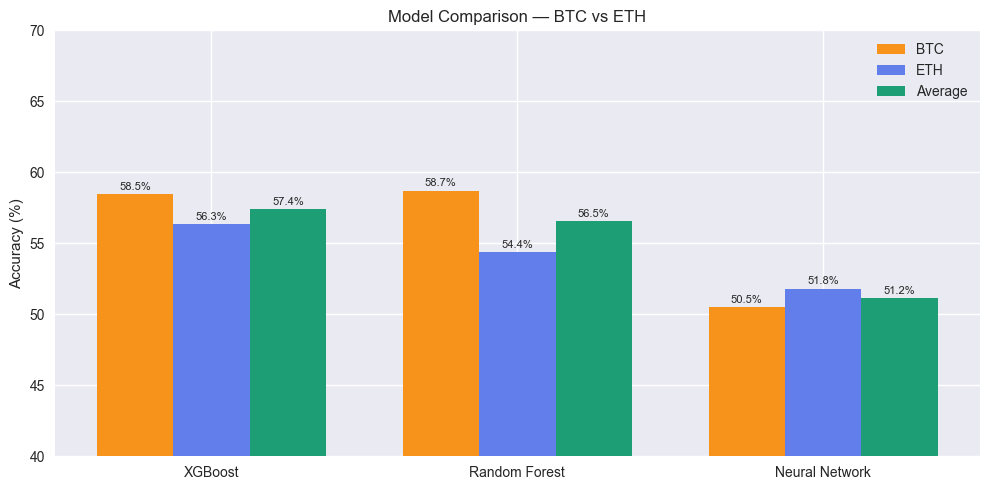

Chart saved!


In [8]:
# Summary comparison
results = {
    'Model': ['Random Forest', 'XGBoost', 'Neural Network'],
    'BTC Accuracy': [
        accuracy_score(btc_y_test, rf_btc_pred)*100,
        accuracy_score(btc_y_test, xgb_btc_pred)*100,
        accuracy_score(btc_y_test, nn_btc_pred)*100,
    ],
    'ETH Accuracy': [
        accuracy_score(eth_y_test, rf_eth_pred)*100,
        accuracy_score(eth_y_test, xgb_eth_pred)*100,
        accuracy_score(eth_y_test, nn_eth_pred)*100,
    ]
}

results_df = pd.DataFrame(results)
results_df['Average'] = (results_df['BTC Accuracy'] + results_df['ETH Accuracy']) / 2
results_df = results_df.sort_values('Average', ascending=False).reset_index(drop=True)

print("Model Comparison:")
print("="*55)
print(results_df.to_string(index=False))
print("="*55)
print(f"\nBest model: {results_df.iloc[0]['Model']}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
width = 0.25
bars1 = ax.bar(x - width, results_df['BTC Accuracy'], width, label='BTC', color='#F7931A')
bars2 = ax.bar(x,         results_df['ETH Accuracy'], width, label='ETH', color='#627EEA')
bars3 = ax.bar(x + width, results_df['Average'],      width, label='Average', color='#1D9E75')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison — BTC vs ETH')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.legend()
ax.set_ylim(40, 70)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../docs/diagrams/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [9]:
import joblib
import os

os.makedirs('../data/models', exist_ok=True)

# Save XGBoost models (best performer)
joblib.dump(xgb_btc, '../data/models/xgb_btc.joblib')
joblib.dump(xgb_eth, '../data/models/xgb_eth.joblib')

# Save scalers (needed for Neural Network later)
joblib.dump(btc_scaler, '../data/models/scaler_btc.joblib')
joblib.dump(eth_scaler, '../data/models/scaler_eth.joblib')

# Save all models too (for comparison in report)
joblib.dump(rf_btc, '../data/models/rf_btc.joblib')
joblib.dump(rf_eth, '../data/models/rf_eth.joblib')
joblib.dump(nn_btc, '../data/models/nn_btc.joblib')
joblib.dump(nn_eth, '../data/models/nn_eth.joblib')

print("Models saved to data/models/:")
for f in os.listdir('../data/models'):
    size = os.path.getsize(f'../data/models/{f}') / 1024
    print(f"  {f} ({size:.1f} KB)")

Models saved to data/models/:
  .gitkeep (0.0 KB)
  nn_btc.joblib (340.1 KB)
  nn_eth.joblib (340.0 KB)
  rf_btc.joblib (3527.8 KB)
  rf_eth.joblib (4676.4 KB)
  scaler_btc.joblib (1.8 KB)
  scaler_eth.joblib (1.8 KB)
  xgb_btc.joblib (1860.8 KB)
  xgb_eth.joblib (2085.7 KB)


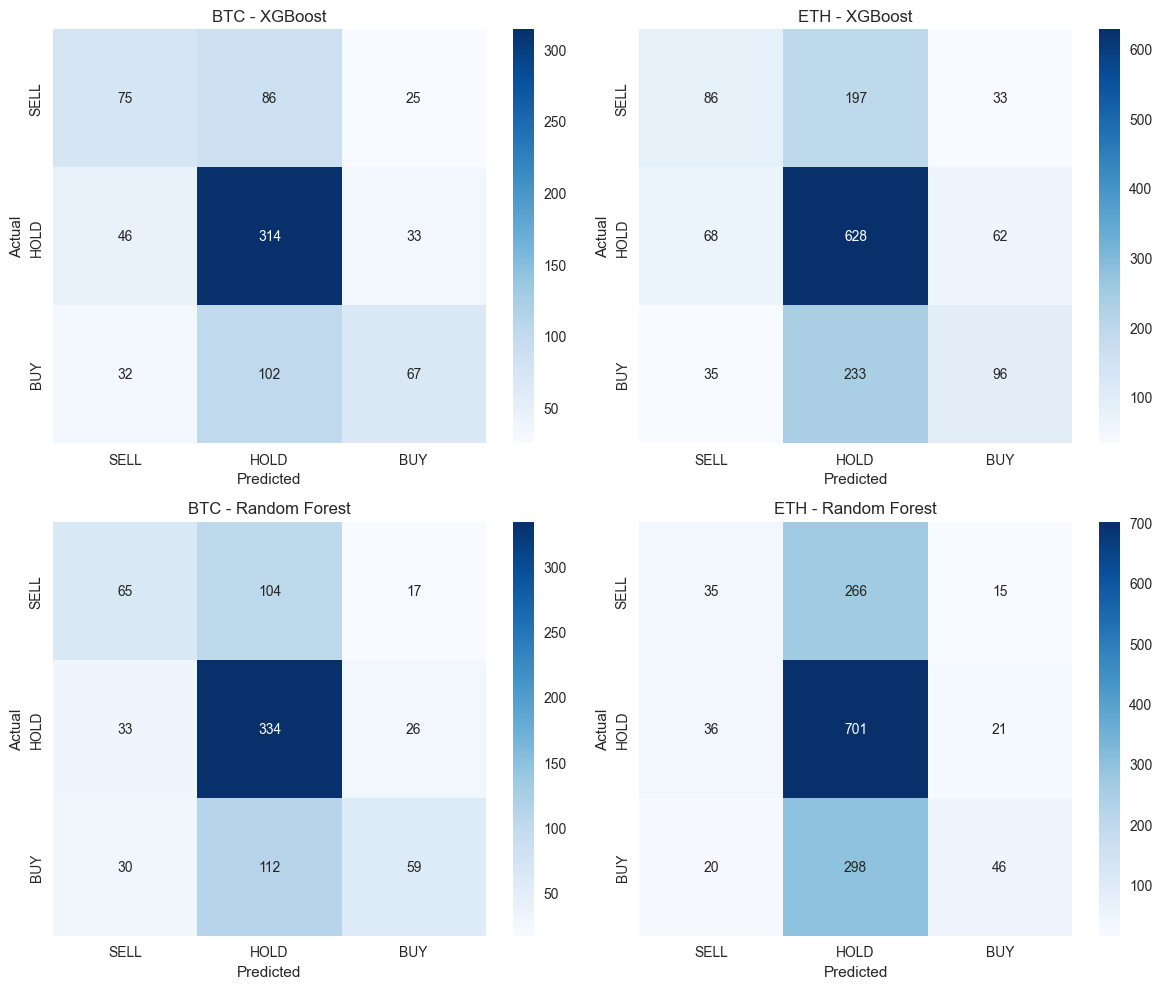

Confusion matrices saved!


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
label_names = ['SELL', 'HOLD', 'BUY']

pairs = [
    (btc_y_test, xgb_btc_pred, 'BTC - XGBoost', axes[0][0]),
    (eth_y_test, xgb_eth_pred, 'ETH - XGBoost', axes[0][1]),
    (btc_y_test, rf_btc_pred,  'BTC - Random Forest', axes[1][0]),
    (eth_y_test, rf_eth_pred,  'ETH - Random Forest', axes[1][1]),
]

for y_true, y_pred, title, ax in pairs:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names,
                ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../docs/diagrams/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved!")